# House Prices: разведочный анализ данных (EDA) для линейной регрессии

**Задача:** предсказать цену дома `SalePrice` (Ames Housing dataset) —
задача **регрессии**, для которой мы будем использовать линейную регрессию
(в финальной версии — Ridge, линейную регрессию с L2-регуляризацией).

**Что в этом ноутбуке:** только разведочный анализ и обоснование решений по
предобработке/инженерии признаков. Код предобработки живёт в
[`src/house_prices_preprocessing.py`](../src/house_prices_preprocessing.py) и
переиспользуется отсюда и из
[`scripts/train_house_prices.py`](../scripts/train_house_prices.py) — то есть
здесь мы объясняем ровно ту логику, которая реально используется при обучении.

**Что НЕ в этом ноутбуке:** обучение модели и метрики — это в
`scripts/train_house_prices.py`. Теория линейной регрессии (МНК, градиентный
спуск, регуляризация, диагностика остатков) — в
[`tutorials/linearregression.ipynb`](../tutorials/linearregression.ipynb).

In [1]:
import os
from pathlib import Path

if not Path("pyproject.toml").exists() and Path("../pyproject.toml").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from src.house_prices_preprocessing import (
    DROP_COLS,
    ONEHOT_COLS,
    ORDINAL_MAPS,
    TARGET_ENCODE_COLS,
    engineer_and_clean,
    fill_missing,
    get_baseline_numeric_columns,
    load_raw,
    log_transform_skewed,
)
from utils.plotting import (
    plot_boxplot_by_category,
    plot_correlation_heatmap,
    plot_missing_values,
    plot_target_distribution,
    set_style,
)

set_style()
pd.set_option("display.max_columns", 20)

train, test = load_raw()
print("train:", train.shape, " test:", test.shape)
train.head()

train: (1460, 81)  test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Общий обзор

79 признаков дома (плюс `Id` и таргет `SalePrice`) — гораздо больше, чем в
Titanic, и с намного более сложной структурой: смесь метровых/долларовых
величин, порядковых шкал качества (`Ex/Gd/TA/Fa/Po`) и номинальных категорий
без порядка.

In [2]:
numeric_cols = train.select_dtypes(include="number").columns
categorical_cols = train.select_dtypes(exclude="number").columns
print(f"Числовых признаков: {len(numeric_cols) - 2}")  # минус Id и SalePrice
print(f"Категориальных признаков: {len(categorical_cols)}")

Числовых признаков: 36
Категориальных признаков: 43


## 2. Целевая переменная — SalePrice

Денежные величины почти всегда скошены вправо: немного очень дорогих домов
растягивают хвост распределения. Для линейной регрессии это важно вдвойне —
один из выводов теста Гаусса-Маркова требует, чтобы **остатки** модели были
гомоскедастичны и примерно нормальны, а скошенный таргет обычно ведёт именно
к гетероскедастичности (подробный разбор — в `tutorials/linearregression.ipynb`).

Skewness SalePrice: 1.88
Skewness log1p(SalePrice): 0.12


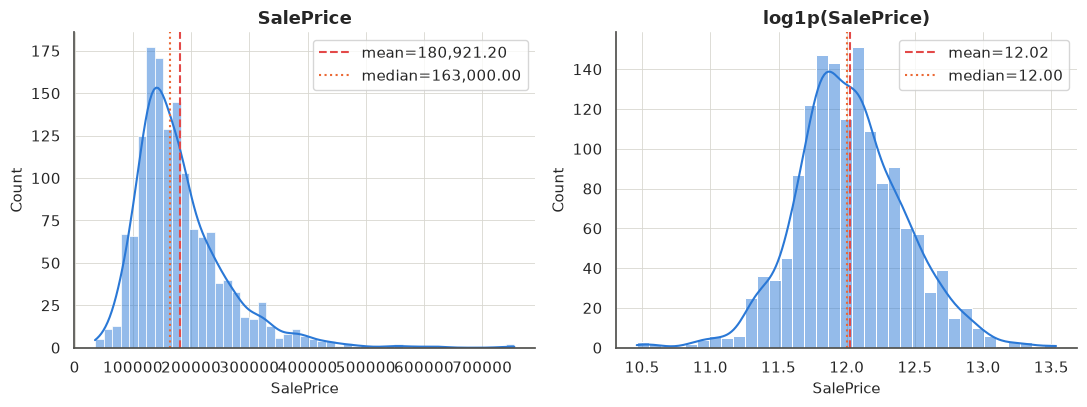

In [3]:
print(f"Skewness SalePrice: {skew(train['SalePrice']):.2f}")
print(f"Skewness log1p(SalePrice): {skew(np.log1p(train['SalePrice'])):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_target_distribution(train["SalePrice"], log=False, title="SalePrice", ax=axes[0])
plot_target_distribution(train["SalePrice"], log=True, title="log1p(SalePrice)", ax=axes[1])
fig.tight_layout()
plt.show()

Скошенность падает с 1.88 до почти нуля — `log1p(SalePrice)` выглядит
практически симметричным. Поэтому в финальной модели обучаем регрессию не на
`SalePrice`, а на `log1p(SalePrice)`, а предсказания переводим обратно через
`expm1()` перед расчётом метрик в долларах (см. `scripts/train_house_prices.py`).
Baseline-модель, наоборот, намеренно учится на исходном `SalePrice` — так
сделал бы новичок, не задумываясь о скошенности.

## 3. Пропущенные значения

Пропуски здесь в основном **не случайны** — `NaN` в `PoolQC` означает
"в доме нет бассейна", а не "данные потерялись". Это принципиально другая
ситуация по сравнению со случайными пропусками, и обрабатывать её нужно
иначе: не медианой/модой, а явной категорией "отсутствует".

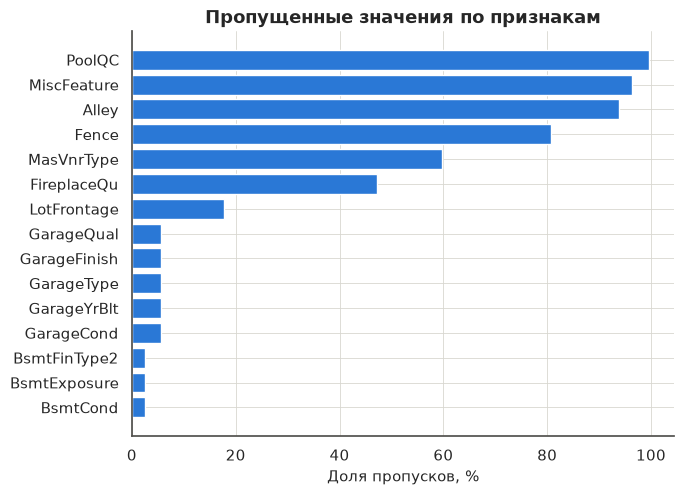

In [4]:
plot_missing_values(train, top_n=15)
plt.show()

In [5]:
missing_pct = train.isna().mean().sort_values(ascending=False)
print(missing_pct[missing_pct > 0.5].round(3))

PoolQC         0.995
MiscFeature    0.963
Alley          0.938
Fence          0.808
MasVnrType     0.597
dtype: float64


Решения (реализованы в `src/house_prices_preprocessing.py`):

- **`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType`** — пропущены у
  50-99% домов. При такой доле пропусков признак несёт мало сигнала
  относительно шума, который вносит его заполнение — удаляем (`DROP_COLS`).
- **Признаки подвала/гаража/камина** (`BsmtQual`, `BsmtExposure`,
  `GarageType`, `FireplaceQu`, ...) — пропуск = "у дома нет подвала/гаража/
  камина". Заполняем явной категорией `"NA"`, которая после порядкового
  кодирования (см. п.6) станет самым низким уровнем шкалы качества, а не
  случайным шумом.
- **`LotFrontage`** (17.7% пропусков) — заполняем медианой **внутри
  `Neighborhood`** (площадь фасада сильно зависит от района), а не общей
  медианой по всей выборке.
- Единичные "сиротские" пропуски (`Electrical`, и несколько только в
  `test.csv`) — заполняются модой/медианой, посчитанной по `train`.

## 4. Корреляция числовых признаков с ценой

Быстрый взгляд на то, какие признаки сильнее всего линейно связаны с
`SalePrice` — хорошая отправная точка (помня, что корреляция Пирсона видит
только линейные связи).

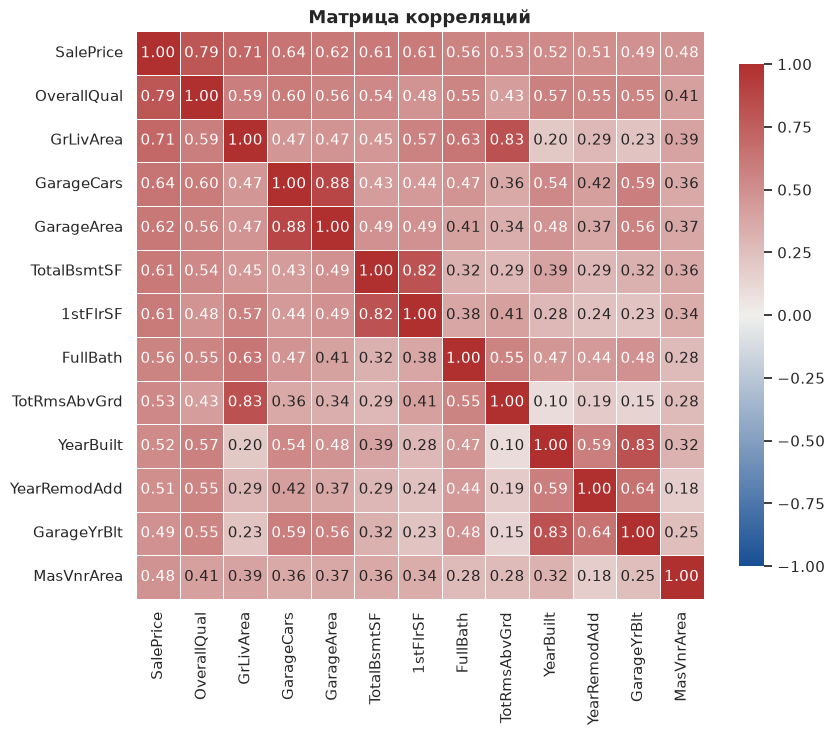

In [6]:
plot_correlation_heatmap(train, target="SalePrice", top_n=12)
plt.show()

## 5. Мультиколлинеарность: главная методическая ловушка этого датасета

`GrLivArea` — это ровно сумма `1stFlrSF + 2ndFlrSF + LowQualFinSF`.
`TotalBsmtSF` — сумма `BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF`. Если оставить в
модели и сумму, и слагаемые — матрица признаков становится вырожденной
(идеальная мультиколлинеарность, $\det(X^TX)=0$), и коэффициенты линейной
регрессии перестают быть однозначно определены. Посмотрим на это через VIF
(Variance Inflation Factor) — чем он выше, тем сильнее конкретный признак
объясняется линейной комбинацией остальных.

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    X = df[cols].fillna(df[cols].median())
    X = X.loc[:, X.std() > 0]  # константные столбцы ломают VIF
    vif = pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
        index=X.columns,
    )
    return vif.sort_values(ascending=False)

collinear_probe = [
    "GrLivArea", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "TotalBsmtSF", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "GarageCars", "GarageArea", "TotRmsAbvGrd", "OverallQual",
]
print("VIF ДО чистки (с суммами и слагаемыми одновременно):")
print(compute_vif(train, collinear_probe).round(1))

VIF ДО чистки (с суммами и слагаемыми одновременно):
GrLivArea        inf
1stFlrSF         inf
2ndFlrSF         inf
LowQualFinSF     inf
TotalBsmtSF      inf
BsmtFinSF1       inf
BsmtFinSF2       inf
BsmtUnfSF        inf
TotRmsAbvGrd    38.4
GarageCars      33.0
GarageArea      29.1
OverallQual     29.1
dtype: float64


/home/arakelov/Ml/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [8]:
after_cols = [c for c in collinear_probe if c not in DROP_COLS]
print("VIF ПОСЛЕ удаления сумм-дублей (DROP_COLS):")
print(compute_vif(train, after_cols).round(1))

VIF ПОСЛЕ удаления сумм-дублей (DROP_COLS):
OverallQual    24.5
1stFlrSF       23.8
GarageCars     10.8
BsmtUnfSF       7.2
BsmtFinSF1      5.8
2ndFlrSF        2.2
dtype: float64


До чистки VIF у `GrLivArea`, `TotalBsmtSF` и их слагаемых буквально уходит в
`inf` — самый явный из возможных признаков идеальной мультиколлинеарности
(суммы линейно выражаются через свои части, `det(XᵀX)=0`). После удаления
признаков-сумм (`DROP_COLS`: `GrLivArea`, `TotalBsmtSF`, `TotRmsAbvGrd`,
`GarageArea`, `BsmtFinSF2`, `GarageYrBlt`, `LowQualFinSF` и высокопропущенные
категориальные) идеальная мультиколлинеарность исчезает: `inf` пропадает,
большинство VIF опускается до однозначных чисел. Но `OverallQual` и
`1stFlrSF` всё ещё держатся в районе 20-25 — и это уже не техническая
проблема (линейная зависимость через сумму), а содержательная: качество
дома и площадь этажа в этом датасете просто на самом деле сильно связаны
между собой. `DROP_COLS` лечит первую, "механическую" причину
мультиколлинеарности; вторую, содержательную, полностью убрать без потери
информации нельзя — с ней в финальной модели борется L2-регуляризация
(`Ridge`), которая явно рассчитана на коррелированные признаки (детали — в
`tutorials/linearregression.ipynb`).

**Отдельный нюанс**, который несложно упустить: если из слагаемых собрать
*новый* агрегированный признак (например, `TotalBath` из четырёх колонок
ванных комнат), то сами исходные слагаемые тоже нужно убрать — иначе
мультиколлинеарность просто возникнет заново между новым признаком и его
компонентами. В `engineer_and_clean()` это сделано явно
(`AGGREGATED_COMPONENT_COLS`).

## 6. Neighborhood — высококардинальный признак

`Neighborhood` — категориальный признак с большим количеством уникальных
значений и заметным разбросом цены между районами.

Уникальных районов: 25


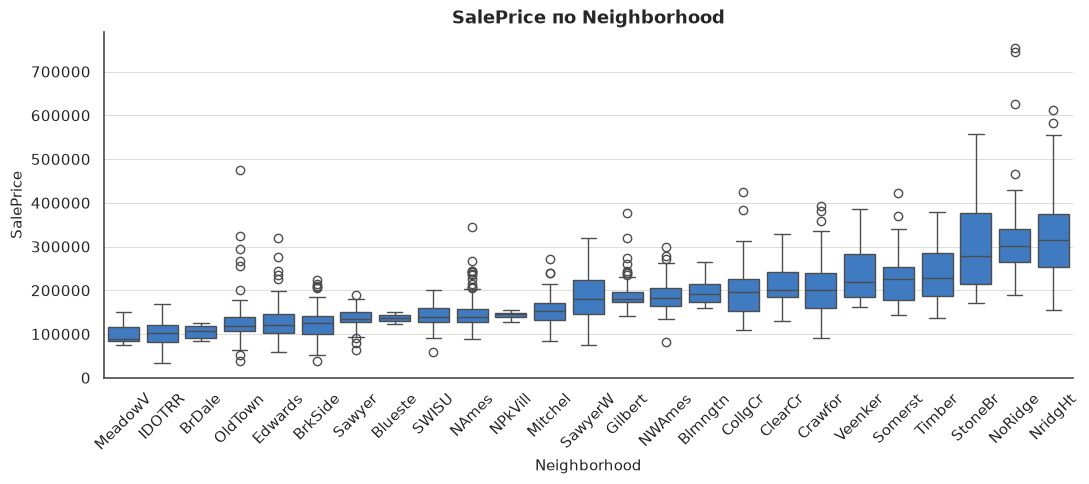

In [9]:
print(f"Уникальных районов: {train['Neighborhood'].nunique()}")
order = train.groupby("Neighborhood")["SalePrice"].median().sort_values().index
plot_boxplot_by_category(train, "Neighborhood", "SalePrice", order=order)
plt.show()

25 категорий — многовато для One-Hot Encoding (25 новых разреженных бинарных
столбцов, каждый почти всегда 0), при этом различие в медианной цене между
районами — почти пятикратное, то есть сигнал сильный и терять его нельзя.
Здесь уместнее **target encoding**: заменить категорию на статистику таргета
внутри неё. Наивный target encoding (посчитать среднюю цену по всей
обучающей выборке и подставить) — это классическая утечка данных: значение
признака для конкретного дома будет неявно "знать" его же цену. Поэтому в
`build_preprocessor()` используется `sklearn.preprocessing.TargetEncoder`,
который считает статистику с внутренним cross-fitting (разбивает train на
фолды и для каждого фолда считает кодировку по остальным) — честно, без
утечки, и не требует ручного разбиения.

## 7. Выбросы

Классический для этого датасета случай: пара домов с очень большой
жилой площадью (`GrLivArea`), но подозрительно низкой ценой — вероятно,
нетипичные сделки (например, распродажа родственникам).

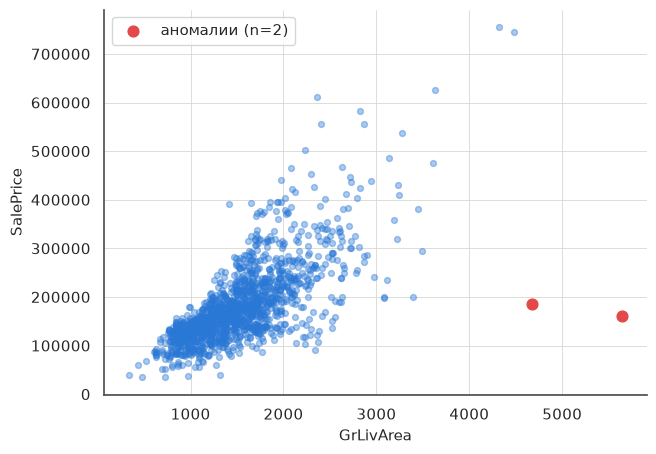

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.4, color="#2a78d6", s=18)
outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
ax.scatter(outliers["GrLivArea"], outliers["SalePrice"], color="#e34948", s=60,
           label=f"аномалии (n={len(outliers)})")
ax.set_xlabel("GrLivArea")
ax.set_ylabel("SalePrice")
ax.legend()
plt.show()

Такие точки резко искажают МНК-решение (метод наименьших квадратов особенно
чувствителен к выбросам — подробности в `tutorials/linearregression.ipynb`).
В этом проекте мы не удаляем их вручную, а вместо этого:

1. Используем `RobustScaler` для числовых признаков — он масштабирует по
   межквартильному размаху, а не по среднему/стд, поэтому меньше подвержен
   влиянию единичных выбросов.
2. Логарифмируем `SalePrice` и сильно скошенные числовые признаки (п.9) —
   это сжимает экстремальные значения ближе к основному облаку точек.

Ручное удаление строк — тоже валидный вариант, но требует аккуратности
(нельзя чистить `test.csv`, только `train`), поэтому в базовом пайплайне
сознательно выбран более безопасный путь через масштабирование и трансформацию.

## 8. Порядковые признаки качества

Многие категориальные признаки на самом деле имеют естественный порядок:
`Po < Fa < TA < Gd < Ex` (Poor → Excellent). Кодировать их через One-Hot —
терять информацию о порядке; через `OrdinalEncoder` с явно заданным порядком
категорий — сохранять её.

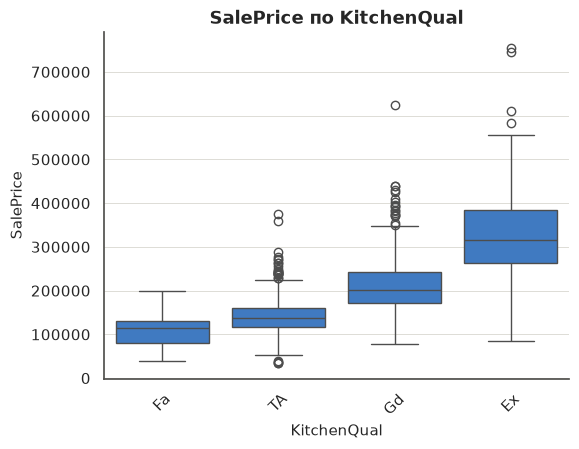

In [11]:
qual_order = ["Fa", "TA", "Gd", "Ex"]  # Po в KitchenQual не встречается
plot_boxplot_by_category(train, "KitchenQual", "SalePrice", order=qual_order)
plt.show()

Зависимость цены от `KitchenQual` строго монотонна — именно то, что и должен
ловить порядковый признак. Полный список из 14 таких колонок
и их шкал — в `ORDINAL_MAPS` (`src/house_prices_preprocessing.py`); признаки
без пропусков вроде `OverallQual`/`OverallCond` в датасете уже числовые
(1-10) и идут в модель как есть.

## 9. Скошенность остальных числовых признаков

Не только `SalePrice` скошен — многие числовые признаки (площади, суммы в
долларах) имеют похожую форму распределения.

In [12]:
train_fe_preview = engineer_and_clean(train)
numeric_preview = get_baseline_numeric_columns(train_fe_preview)
skewness = train_fe_preview[numeric_preview].apply(lambda s: skew(s.dropna())).sort_values(ascending=False)
skewed = skewness[skewness.abs() > 0.75]
print(f"Признаков со |skew| > 0.75: {len(skewed)} из {len(numeric_preview)}")
skewed.head(10).round(2)

Признаков со |skew| > 0.75: 14 из 27


MiscVal         24.45
PoolArea        14.81
LotArea         12.20
KitchenAbvGr     4.48
MasVnrArea       2.67
LotFrontage      2.16
QualArea         2.02
TotalPorchSF     2.00
BsmtFinSF1       1.68
WoodDeckSF       1.54
dtype: float64

Все они логарифмируются функцией `log_transform_skewed()` — список признаков
для трансформации фиксируется **по train** (см. п.7 план по выбросам — та же
логика "не подглядывать в test"), а затем то же преобразование применяется
к `train`/`holdout`/`test` одинаково.

## 10. Инженерия признаков: собираем всё вместе

`engineer_and_clean()` создаёт новые признаки и сразу удаляет как исходные
дубли-мультиколлинеарность (п.5), так и сырьё, из которого агрегаты собраны:

In [13]:
before_cols = set(train.columns)
after_cols = set(train_fe_preview.columns)

print("Новые признаки:", sorted(after_cols - before_cols))
print("Удалённые признаки:", sorted(before_cols - after_cols))
print(f"\nБыло колонок: {len(before_cols)}  Стало: {len(after_cols)}")

Новые признаки: ['HouseAge', 'IsRemodeled', 'QualArea', 'RemodAge', 'TotalBath', 'TotalPorchSF']
Удалённые признаки: ['3SsnPorch', 'Alley', 'BsmtFinSF2', 'BsmtFullBath', 'BsmtHalfBath', 'EnclosedPorch', 'Fence', 'FullBath', 'GarageArea', 'GarageYrBlt', 'GrLivArea', 'HalfBath', 'LowQualFinSF', 'MasVnrType', 'MiscFeature', 'OpenPorchSF', 'PoolQC', 'ScreenPorch', 'TotRmsAbvGrd', 'TotalBsmtSF']

Было колонок: 81  Стало: 67


- `QualArea = OverallQual * GrLivArea` — взаимодействие качества и площади
  (большой дом низкого качества ценится иначе, чем маленький, но качественный).
- `TotalBath`, `TotalPorchSF` — агрегаты вместо 4-6 разрозненных колонок.
- `HouseAge = YrSold - YearBuilt`, `RemodAge = YrSold - YearRemodAdd`,
  `IsRemodeled` — возраст дома интерпретируется моделью проще, чем два
  сырых года.

## 11. Итог: план предобработки для финальной модели

| Тип признаков | Примеры | Обработка |
|---|---|---|
| Числовые (площади, годы, счётчики) | `LotArea`, `HouseAge`, `TotalBath` | пропуски → медиана/0, log1p для скошенных, `RobustScaler` |
| Порядковые шкалы качества | `KitchenQual`, `BsmtExposure`, `Functional` | пропуски → `"NA"`, `OrdinalEncoder` с заданным порядком |
| Номинальные категории | `MSZoning`, `HouseStyle`, `SaleCondition` | пропуски → мода, `OneHotEncoder` |
| Высококардинальный `Neighborhood` | — | `TargetEncoder` (честный, с cross-fitting) |
| Таргет `SalePrice` | — | `log1p` при обучении, `expm1` при оценке метрик |

Baseline-модель (для сравнения) — `LinearRegression` на всех сырых числовых
колонках как есть, с одной лишь медианной импутацией: без чистки
мультиколлинеарности, без кодирования категорий, без лог-таргета. Реальные
метрики baseline и финальной модели (`Ridge` с CV-подбором `alpha`) —
в `models/house_prices/metrics.json` (воспроизводится
`python scripts/train_house_prices.py`) и в [README.md](../README.md).